In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from uncertainties import ufloat_fromstr
import os
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Trebuchet MS'

In [2]:
color_saf = 'coral'  # Color for SAF bars
color_daccs = 'lightskyblue'  # Color for DACCS bars
color_contrail = "palegreen" 
color_ht = "indianred"

In [3]:
sensitivity = True

In [4]:
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
root = os.path.dirname(notebook_dir)
folder_name_base = "2025-05-05"
sensitivity_name = "Default"
if sensitivity:
    folder_name = os.path.join(folder_name_base, sensitivity_name)
else:
    folder_name = folder_name_base
scenarios = {
    0 : "Base Case",
    1 : "CA_both",
    2 : "CA_both_HT_Fossil_SO2_y",
    3 : "CA_both_HT_Fossil_SO2_n",
    4 : "HT_Fossil_SO2_y",
    5 : "HT_Fossil_SO2_n"
}
# Change this to affect which scenario is plotted.
scenario_selection = 0
sheet_name = scenarios[scenario_selection]

In [5]:
# Define paths for abatement cost data

file_path_gwp_star_saf = os.path.join(notebook_dir, root, "outputs", folder_name, "abatement_costs_saf_GWP_star.xlsx")
file_path_gwp_20_saf = os.path.join(notebook_dir, f'{root}/outputs/{folder_name}/abatement_costs_saf_GWP20.xlsx')
file_path_gwp_100_saf = os.path.join(notebook_dir, f'{root}/outputs/{folder_name}/abatement_costs_saf_GWP100.xlsx')

file_path_gwp_star_daccs = os.path.join(notebook_dir, f'{root}/outputs/{folder_name}/abatement_costs_daccs_GWP_star.xlsx')
file_path_gwp_20_daccs = os.path.join(notebook_dir, f'{root}/outputs/{folder_name}/abatement_costs_daccs_GWP20.xlsx')
file_path_gwp_100_daccs = os.path.join(notebook_dir, f'{root}/outputs/{folder_name}/abatement_costs_daccs_GWP100.xlsx')


In [6]:
# Read abatement cost data

abatement_cost_gwp_star_saf = pd.read_excel(file_path_gwp_star_saf, sheet_name=sheet_name)
abatement_cost_gwp_20_saf = pd.read_excel(file_path_gwp_20_saf, sheet_name=sheet_name)
abatement_cost_gwp_100_saf = pd.read_excel(file_path_gwp_100_saf, sheet_name=sheet_name)

abatement_cost_gwp_star_daccs = pd.read_excel(file_path_gwp_star_daccs, sheet_name=sheet_name)
abatement_cost_gwp_20_daccs =  pd.read_excel(file_path_gwp_20_daccs, sheet_name=sheet_name)
abatement_cost_gwp_100_daccs = pd.read_excel(file_path_gwp_100_daccs, sheet_name=sheet_name)

In [7]:
# Read abatement cost curves ($/tCO2)
abatement_cost_curve_saf = pd.read_excel(os.path.join(notebook_dir, '../outputs/abatement_cost_curve_saf.xlsx'), sheet_name='Sheet1')
abatement_cost_curve_daccs = pd.read_excel(os.path.join(notebook_dir, '../outputs/abatement_cost_curve_daccs.xlsx'), sheet_name='Sheet1')

In [8]:
# Read DACCS data
daccs_df = pd.read_excel("../data/Master Standardisation DACCS.xlsx", sheet_name="Standardization Results", skiprows=1)
# Drop rows where technology is 0
daccs_df = daccs_df[daccs_df['DAC Technology'] != 0]
daccs_df = daccs_df.dropna(subset = "Baseline $2023 Any Cost Type")
daccs_df.replace("Ambient Weathering", "Ambient weathering", inplace=True)
daccs_df.loc[:,"DAC Technology"] = daccs_df.loc[:,"DAC Technology"].str.strip()
# Drop membrane based
daccs_df = daccs_df[daccs_df['DAC Technology'] != "Membrane-based m-DAC"]
# Year of assumption before 20Abatement Cost $ per tCO2eq
daccs_df.loc[:,"Year of Assumptions in Study"] = daccs_df["Year of Assumptions in Study"].astype(int)

In [9]:
# Select spcific DACCS studies from df 
# Young et al. 2023
# Sievert et al. 20Abatement Cost $ per tCO2eq
# Fasihi et al. 2019
# Keith et al. 2018

studies_to_keep_daccs = ["Young et al. 2023", "Sievert et al. 2024", "Fasihi et al. 2019", "Keith et al. 2018", "Pett-Ridge et al. 2024"]
daccs_df = daccs_df[daccs_df['Reference'].isin(studies_to_keep_daccs)]
# Add the term column which is short term if year of assumption is less than 2030
daccs_df.loc[daccs_df['Year of Assumptions in Study'] < 2025, "Term"] = "Short Term"
daccs_df.loc[daccs_df['Year of Assumptions in Study'] >= 2025, "Term"] = "Long Term"

In [10]:
daccs_df

,Reference,Year of Assumptions in Study,DOI,DAC Technology,Technology Detail,Year of Cost Currency,Year of Cost,Currency shown,Study Scenario,Cost type,...,Fully Harmonized NET REMOVED COST (incl T&S,Electricity,CO2,CAPEX,Other OPEX,Study Type,Plant Location,Production,Notes,Term
0,Young et al. 2023,2022,10.1016/j.oneear.2023.06.004,Liquid solvent,KOH absorption paired with regeneration via Ca...,2019 USD,2019.0,USD,Reference,Net removed cost,...,414.854259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Short Term
1,Young et al. 2023,2022,10.1016/j.oneear.2023.06.004,Liquid solvent,KOH absorption paired with regeneration via Ca...,2019 USD,2019.0,USD,Low net removed cost,Net removed cost,...,342.503584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Short Term
2,Young et al. 2023,2022,10.1016/j.oneear.2023.06.004,Liquid solvent,KOH absorption paired with regeneration via Ca...,2019 USD,2019.0,USD,High net removed cost,Net removed cost,...,523.951742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Short Term
3,Young et al. 2023,2050,10.1016/j.oneear.2023.06.004,Liquid solvent,KOH absorption paired with regeneration via Ca...,2019 USD,2019.0,USD,Reference,Net removed cost,...,187.761963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Long Term
4,Young et al. 2023,2050,10.1016/j.oneear.2023.06.004,Liquid solvent,KOH absorption paired with regeneration via Ca...,2019 USD,2019.0,USD,Low net removed cost,Net removed cost,...,125.324636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Long Term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Pett-Ridge et al. 2024,2050,Roads to Removal – Options for carbon dioxide ...,Solid sorbent,Solid sorbent DAC using temperature vacuum swi...,2050 USD,2024.0,USD,High Electricity Price,NaN,...,147.497072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Long Term
163,Pett-Ridge et al. 2024,2025,Roads to Removal – Options for carbon dioxide ...,Liquid solvent,KOH absorption paired with regeneration via Ca...,2024 USD,2024.0,USD,Scenario A,NaN,...,440.012168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Long Term
164,Pett-Ridge et al. 2024,2025,Roads to Removal – Options for carbon dioxide ...,Liquid solvent,KOH absorption paired with regeneration via Ca...,2024 USD,2024.0,USD,Scenario C,NaN,...,339.041434,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Long Term
165,Pett-Ridge et al. 2024,2025,Roads to Removal – Options for carbon dioxide ...,Liquid solvent,KOH absorption paired with regeneration via Ca...,2024 USD,2024.0,USD,Scenario D,NaN,...,263.410198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Long Term


In [11]:
# Read Synfuels data
synfuels_df_med = pd.read_excel("../data/Master Standardisation_SAF_Default.xlsx", sheet_name="Standardization Results", skiprows=0)
synfuels_df_high = pd.read_excel("../data/Master Standardisation_SAF_Default.xlsx", sheet_name="High CO2", skiprows=0)
synfuels_df_low = pd.read_excel("../data/Master Standardisation_SAF_Default.xlsx", sheet_name="Low CO2", skiprows=0)

# Select specific synfuels studies

studies_to_keep_synfuels = ["Brazzola et al. ", "Gray et al.", "Marchese et.al. ", "Martin et. al.", "Moretti et al.",
                     "Peacock et. al.", "Schmidt et. al.", "Seymour et al.", "Sherwin"]

synfuels_df_med = synfuels_df_med[synfuels_df_med['Reference'].isin(studies_to_keep_synfuels)]
synfuels_df_high = synfuels_df_high[synfuels_df_high['Reference'].isin(studies_to_keep_synfuels)]
synfuels_df_low = synfuels_df_low[synfuels_df_low['Reference'].isin(studies_to_keep_synfuels)]

synfuels_df_med["Year of Cost"] = synfuels_df_med["Year of Cost"].astype(int)
synfuels_df_high["Year of Cost"] = synfuels_df_high["Year of Cost"].astype(int)
synfuels_df_low["Year of Cost"] = synfuels_df_low["Year of Cost"].astype(int)

# Define a term column which is Short Term if Year of Cost is before 2030 and Long Term if after 2030
synfuels_df_med["Term"] = np.where(synfuels_df_med["Year of Cost"] < 2030, "Short Term", "Long Term")
synfuels_df_high["Term"] = np.where(synfuels_df_high["Year of Cost"] < 2030, "Short Term", "Long Term")
synfuels_df_low["Term"] = np.where(synfuels_df_low["Year of Cost"] < 2030, "Short Term", "Long Term")

synfuel_dfs = [synfuels_df_med, synfuels_df_high, synfuels_df_low]
synfuels_df = pd.concat(synfuel_dfs)

In [12]:
abatement_cost_gwp_star_saf.loc[:,"Abatement Cost $ per tCO2eq"]= abatement_cost_gwp_star_saf.loc[:,"Abatement Cost $ per tCO2eq"].astype(str).apply(lambda x: ufloat_fromstr(x)) # Converts ufloats from string
abatement_cost_gwp_star_daccs.loc[:,"Abatement Cost $ per tCO2eq"] = abatement_cost_gwp_star_daccs.loc[:,"Abatement Cost $ per tCO2eq"].astype(str).apply(lambda x: ufloat_fromstr(x))
abatement_cost_gwp_star_saf[["Abatement Cost Low", "Abatement Cost High", "Abatement Cost Nominal", "Standard Deviation"]] = abatement_cost_gwp_star_saf["Abatement Cost $ per tCO2eq"].apply(
    lambda x: pd.Series({
        "Abatement Cost Low": x.nominal_value - x.std_dev,
        "Abatement Cost High": x.nominal_value + x.std_dev,
        "Abatement Cost Average": x.nominal_value,
        "Standard Deviation": x.std_dev
    })
)
abatement_cost_gwp_star_daccs[["Abatement Cost Low", "Abatement Cost High", "Abatement Cost Nominal", "Standard Deviation"]] = abatement_cost_gwp_star_daccs["Abatement Cost $ per tCO2eq"].apply(
    lambda x: pd.Series({
        "Abatement Cost Low": x.nominal_value - x.std_dev,
        "Abatement Cost High": x.nominal_value + x.std_dev,
        "Abatement Cost Average": x.nominal_value,
        "Standard Deviation": x.std_dev
    })
)
abatement_cost_saf_dfs = {"GWP20": abatement_cost_gwp_20_saf, "GWP100": abatement_cost_gwp_100_saf, "GWP*": abatement_cost_gwp_star_saf}
abatement_cost_daccs_dfs = {"GWP20": abatement_cost_gwp_20_daccs, "GWP100": abatement_cost_gwp_100_daccs, "GWP*": abatement_cost_gwp_star_daccs}

In [13]:
for df in abatement_cost_saf_dfs.values():
    df.rename(columns = {'Unnamed: 0':'Quartile'}, inplace = True)
for df in abatement_cost_daccs_dfs.values():
    df.rename(columns = {'Unnamed: 0':'Quartile'}, inplace = True)

In [14]:
# GWP abatement cost dfs are those that don't have GWP* in the name
gwp_abatement_cost_saf_dfs = {k: v for k, v in abatement_cost_saf_dfs.items() if "GWP*" not in k}
gwp_abatement_cost_daccs_dfs = {k: v for k, v in abatement_cost_daccs_dfs.items() if "GWP*" not in k}

In [15]:
if not os.path.exists(f"{root}/outputs/{folder_name}/figures"):
    os.makedirs(f"{root}/outputs/{folder_name}/figures")

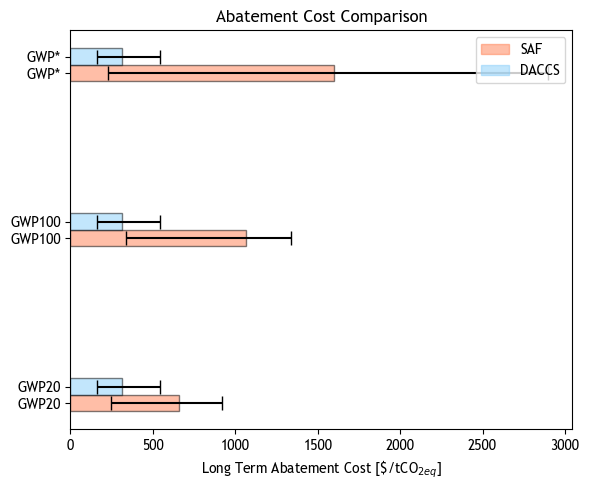

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))  # Adjusted width for additional bars
bar_height = 0.1  # Height of each bar

y_positions = []
labels = []

# Plot SAF bars
for i, (df_name, saf_df) in enumerate(gwp_abatement_cost_saf_dfs.items()):
    saf_df["Abatement Cost $ per tCO2eq"] = saf_df["Abatement Cost $ per tCO2eq"].astype(str).apply(lambda x: ufloat_fromstr(x))
    median_cost = saf_df.loc[saf_df["Quartile"] == "50%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value
    lower_cost = saf_df.loc[saf_df["Quartile"] == "25%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value
    upper_cost = saf_df.loc[saf_df["Quartile"] == "75%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value
    
    y_position = i
    ax.barh(y_position, median_cost, bar_height, color=color_saf, alpha=0.5, edgecolor='black')
    ax.errorbar(median_cost, y_position, xerr=[[median_cost-lower_cost], [upper_cost-median_cost]], color='black', capsize=5, capthick=1, fmt='none')
    
    y_positions.append(y_position)
    labels.append(df_name)

# Plot DACCS bars
for i, (df_name, df) in enumerate(gwp_abatement_cost_daccs_dfs.items()):
    df["Abatement Cost $ per tCO2eq"] = df["Abatement Cost $ per tCO2eq"].astype(str).apply(lambda x: ufloat_fromstr(x))
    median_cost = df.loc[df["Quartile"] == "50%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value
    lower_cost = df.loc[df["Quartile"] == "25%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value
    upper_cost = df.loc[df["Quartile"] == "75%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value
    
    y_position = i + bar_height  # Shift DACCS bar downward
    ax.barh(y_position, median_cost, bar_height, color=color_daccs, alpha=0.5, edgecolor='black')
    ax.errorbar(median_cost, y_position, xerr=[[median_cost-lower_cost], [upper_cost-median_cost]], color='black', capsize=5, capthick=1, fmt='none')
    
    y_positions.append(y_position)
    labels.append(df_name)

# Add the SAF GWP* bar
y_position = len(gwp_abatement_cost_saf_dfs)
abatement_cost_gwp_star_saf.set_index("Quartile", inplace=True)
median_cost = abatement_cost_gwp_star_saf.loc["50%", "Abatement Cost Nominal"]
lower_cost = abatement_cost_gwp_star_saf.loc["25%", "Abatement Cost Low"]
upper_cost = abatement_cost_gwp_star_saf.loc["75%", "Abatement Cost High"]

ax.barh(y_position, median_cost, bar_height, color=color_saf, alpha=0.5, edgecolor='black')
ax.errorbar(median_cost, y_position, xerr=[[median_cost - lower_cost], [upper_cost - median_cost]], color='black', capsize=5, capthick=1, fmt='none')

y_positions.append(y_position)
labels.append("GWP*")

# Add the DACCS GWP* bar
y_position = len(gwp_abatement_cost_saf_dfs) + bar_height
abatement_cost_gwp_star_daccs.set_index("Quartile", inplace=True)
median_cost = abatement_cost_gwp_star_daccs.loc["50%", "Abatement Cost Nominal"]
lower_cost = abatement_cost_gwp_star_daccs.loc["25%", "Abatement Cost Low"]
upper_cost = abatement_cost_gwp_star_daccs.loc["75%", "Abatement Cost High"]

ax.barh(y_position, median_cost, bar_height, color=color_daccs, alpha=0.5, edgecolor='black')
ax.errorbar(median_cost, y_position, xerr=[[median_cost - lower_cost], [upper_cost - median_cost]], color='black', capsize=5, capthick=1, fmt='none')

y_positions.append(y_position)
labels.append("GWP*")

# Customize plot
ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_xlabel(r"Long Term Abatement Cost [\$/tCO$_{2eq}$]")
ax.set_title("Abatement Cost Comparison")
ax.set_xlim(left=0)

# Add legend
custom_legend = [
    Patch(color=color_saf, alpha=0.5, edgecolor='black', label="SAF"),
    Patch(color=color_daccs, alpha=0.5, edgecolor='black', label="DACCS"),
]
ax.legend(handles=custom_legend, loc='upper right')

# Adjust layout and show plot
plt.tight_layout()
plt.savefig(os.path.join(notebook_dir, f"{root}/outputs/{folder_name}/figures/abatement_cost_comparison.png"))
plt.show()

In [17]:
years = np.arange(2025,2050,1)
percentile_25th_values_daccs = abatement_cost_curve_daccs["25%"]
percentile_75th_values_daccs = abatement_cost_curve_daccs["75%"]

percentile_25th_values_synfuels = abatement_cost_curve_saf["25%"]
percentile_75th_values_synfuels = abatement_cost_curve_saf["75%"]


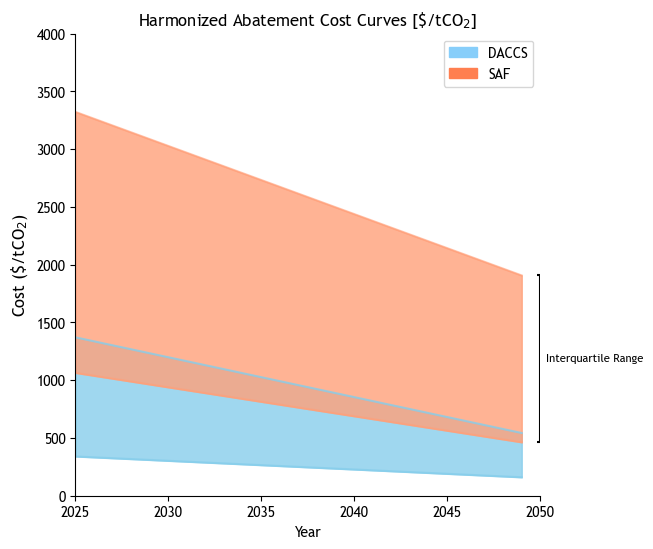

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.ylim(0, 4000)
plt.xlim(2025, 2050)

# Plot DACCS
ax.plot(years, percentile_25th_values_daccs, color='skyblue', alpha=0.8)
ax.plot(years, percentile_75th_values_daccs, color='skyblue', alpha=0.8)
ax.fill_between(years, percentile_25th_values_daccs, percentile_75th_values_daccs, color='skyblue', alpha=0.8)

# Plot Synfuels
ax.plot(years, percentile_25th_values_synfuels, color='lightsalmon', alpha=0.6)
ax.plot(years, percentile_75th_values_synfuels, color='lightsalmon', alpha=0.6)
ax.fill_between(years, percentile_25th_values_synfuels, percentile_75th_values_synfuels, color='lightsalmon', alpha=0.8)

# Custom legend patches
daccs_patch = Patch(color=color_daccs, label='DACCS')
synfuels_patch = Patch(color=color_saf, label='SAF')

# Add custom legend
ax.legend(handles=[daccs_patch, synfuels_patch], loc='upper right')

# Hide top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the title and labels
ax.set_title(r'Harmonized Abatement Cost Curves [\$/tCO$_2$]', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel(r'Cost (\$/tCO$_2$)', fontsize=12)

# Remove grid
ax.grid(False)

# Add bracket markers and text at the end of each plot region
end_year = 2050
dac_25th = percentile_25th_values_daccs.iloc[-1]
dac_75th = percentile_75th_values_daccs.iloc[-1]
synfuel_25th = percentile_25th_values_synfuels.iloc[-1]
synfuel_75th = percentile_75th_values_synfuels.iloc[-1]

# Synfuels bracket and text
ax.vlines(end_year, synfuel_25th, synfuel_75th, color='black', linewidth=1.5)
ax.hlines([synfuel_25th, synfuel_75th], end_year - 0.2, end_year + 0.2, color='black', linewidth=1.5)
ax.text(end_year + 0.3, (synfuel_25th + synfuel_75th) / 2, 'Interquartile Range', color='black', va='center', fontsize=8)
plt.savefig(os.path.join(notebook_dir, f"{root}/outputs/{folder_name}/figures/abatement_cost_curves.png"))
plt.show()

In [19]:
# Rename liquid solvent to liquid solvent with thermal regeneration
daccs_df.loc[daccs_df["DAC Technology"] == "Liquid solvent","DAC Technology"] = "Liquid solvent with thermal regeneration"

In [20]:
synfuels_df

,Reference,Year of Assumptions in Study,DOI,Pathway,Pathway Detail,Year of Cost,Study Scenario,Baseline,LCOE Harmonized,CO2 Cost Harmonized,...,Residual Emissions (gCO2eq/L fuel),Electricity,CO2,CAPEX,Other OPEX,Study Type,Plant Location,Production,Unnamed: 19,Term
2,Brazzola et al.,2024,NaN,e-Fuels,Fischer Tropsch,2024,Reference,432.436036,859.504233,1354.460119,...,0.000000,NaN,NaN,NaN,NaN,Academic,Worldwide,-,NaN,Short Term
3,Brazzola et al.,2024,NaN,e-Fuels,Fischer Tropsch,2050,Reference,226.434837,507.549635,799.828217,...,0.000000,NaN,NaN,NaN,NaN,Academic,Worldwide,-,NaN,Long Term
8,Gray et al.,2024,https://doi.org/10.1016/j.rser.2024.114552,e-Fuels,Fischer Tropsch,2024,Reference DAC Deployment,2727.577326,2805.955159,2708.859962,...,276.927077,0.206021,0.636592,0.107347,0.050039,Academic,Europe,39140033.75,NaN,Short Term
9,Gray et al.,2024,https://doi.org/10.1016/j.rser.2024.114552,e-Fuels,Fischer Tropsch,2050,High DAC Deployment,1053.015690,1131.393522,1614.225461,...,276.927077,0.334702,0.409609,0.174396,0.081294,Academic,Europe,39140033.75,This scenario assumes a decline in CO2 cost bu...,Long Term
10,Marchese et.al.,2021,https://doi.org/10.1016/j.jcou.2021.101487,e-Fuels,Fischer Tropsch,2024,C.4,1458.348939,751.427188,1806.036514,...,0.000000,NaN,NaN,NaN,NaN,Academic,Europe,69000000,NaN,Short Term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,Schmidt et. al.,2024,https://onlinelibrary.wiley.com/doi/full/10.10...,e-Fuels,Fischer Tropsch,2024,EU-South,1286.159301,1276.902166,1452.587516,...,204.668640,NaN,NaN,NaN,NaN,Industrial,Europe,1000000,NaN,Short Term
42,Seymour et al.,2024,https://doi.org/10.1039/D3SE00978E,e-Fuels,Fischer Tropsch,2050,Reference,722.872772,896.607843,825.460528,...,305.140000,0.552030,0.208833,0.156565,0.082572,Academic,United States of America,2110761,NaN,Long Term
43,Seymour et al.,2024,https://doi.org/10.1039/D3SE00978E,e-Fuels,Fischer Tropsch,2024,Reference,1703.294188,1744.099290,1253.528163,...,305.140000,0.452672,0.221750,0.213660,0.111918,Academic,United States of America,2110761,"High CO2 cost assumed, hence there is less effect",Short Term
44,Sherwin,2021,https://doi.org/10.1021/acs.est.0c07955,e-Fuels,Fischer Tropsch,2024,Reference,1330.231544,1583.370213,1356.234125,...,0.000000,NaN,NaN,NaN,NaN,Academic,United States of America,-,NaN,Short Term


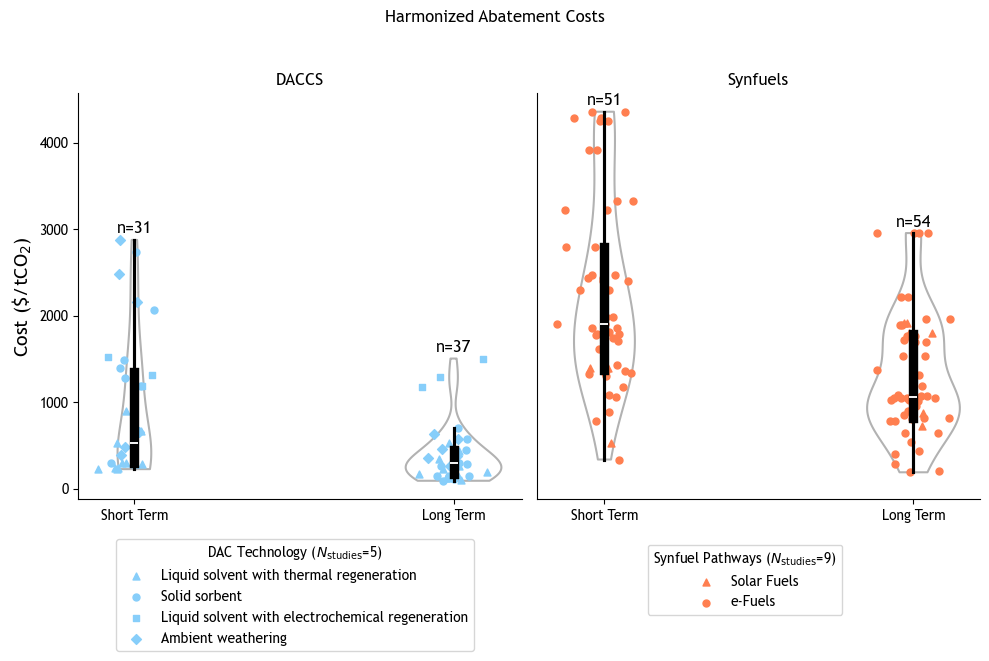

In [21]:
# Define symbol dictionaries
dac_symbols = {
    'Liquid solvent with thermal regeneration': "^",
    'Solid sorbent': "o",
    'Liquid solvent with electrochemical regeneration': "s",
    'Ambient weathering': "D"
}

synfuel_symbols = {
    'Solar Fuels': "^",
    'e-Fuels': "o"
}

# Count unique references for DACCS and Synfuels
num_dac_studies = daccs_df['Reference'].nunique()
num_synfuel_studies = synfuels_df['Reference'].nunique()

# Create figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
fig.suptitle('Harmonized Abatement Costs')

# DACCS Studies violin plot with single color
sns.violinplot(
    data=daccs_df, x="Term", y="Fully Harmonized NET REMOVED COST (incl T&S", 
    inner="box", color="black", fill = False, cut=0, width=0.3, orient='v', alpha=0.3, ax=axs[0]
)

# Overlay symbols with jittered scatter points for DACCS studies
terms_dac = daccs_df['Term'].unique()
term_to_index_dac = {term: idx for idx, term in enumerate(terms_dac)}

for dac_type, marker in dac_symbols.items():
    subset = daccs_df[daccs_df['DAC Technology'] == dac_type]
    x_jittered = [term_to_index_dac[term] + np.random.normal(0, 0.05) for term in subset['Term']]
    axs[0].scatter(
        x=x_jittered,  # jittered x-position
        y=subset["Fully Harmonized NET REMOVED COST (incl T&S"], 
        color=color_daccs, s=25, alpha=1, marker=marker, label=dac_type
    )

# Annotate with number of data points
for term, subset in daccs_df.groupby("Term"):
    count = len(subset)
    axs[0].text(term_to_index_dac[term], subset["Fully Harmonized NET REMOVED COST (incl T&S"].max() + 75,
                f'n={count}', ha='center', color="black", fontsize=12)

axs[0].set_ylabel(r'Cost (\$/tCO$_2$)', fontsize=14)

# Synfuels Studies violin plot with single color
sns.violinplot(
    data=synfuels_df, x="Term", y="Fully Harmonized", 
    inner="box", color="black", fill = False, cut=0, width=0.3, orient='v', alpha=0.3, ax=axs[1]
)

# Overlay symbols with jittered scatter points for Synfuels
terms_synfuel = synfuels_df['Term'].unique()
term_to_index_synfuel = {term: idx for idx, term in enumerate(terms_synfuel)}

for synfuel_type, marker in synfuel_symbols.items():
    subset = synfuels_df[synfuels_df['Pathway'] == synfuel_type]
    x_jittered = [term_to_index_synfuel[term] + np.random.normal(0, 0.05) for term in subset['Term']]
    axs[1].scatter(
        x=x_jittered,  # jittered x-position
        y=subset["Fully Harmonized"], 
        color=color_saf, s=25, alpha=1, marker=marker, label=synfuel_type
    )

# Annotate with number of data points
for term, subset in synfuels_df.groupby("Term"):
    count = len(subset)
    axs[1].text(term_to_index_synfuel[term], subset["Fully Harmonized"].max() + 75,
                f'n={int(count)}', ha='center', color="black", fontsize=12)

# Set titles
axs[0].set_title('DACCS')
axs[1].set_title('Synfuels')

# Remove x-axis label on both panels
axs[0].set_xlabel("")
axs[1].set_xlabel("")

# Hide y-axis ticks on the second panel
axs[1].tick_params(left=False)

# Hide top and right spines for a cleaner look
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set legends outside the subplots below the graph
fig.legend(handles=axs[0].get_legend_handles_labels()[0],
           labels=axs[0].get_legend_handles_labels()[1],
           loc='lower center', bbox_to_anchor=(0.3, -0.1), title=f"DAC Technology ($N_{{\\text{{studies}}}}$={num_dac_studies})")

fig.legend(handles=axs[1].get_legend_handles_labels()[0],
           labels=axs[1].get_legend_handles_labels()[1],
           loc='lower center', bbox_to_anchor=(0.75, -0.04), title=f"Synfuel Pathways ($N_{{\\text{{studies}}}}$={num_synfuel_studies})")

# Remove grids
axs[0].grid(False)
axs[1].grid(False)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Adjust layout to fit title and legends
plt.show()

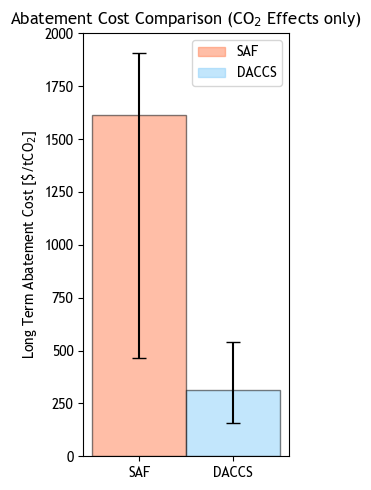

In [22]:
fig,ax = plt.subplots(figsize=(3,5))

bar_width_p = 0.05  # Width of each bar
color_saf = 'coral'  # Color for SAF bars
color_daccs = 'lightskyblue'  # Color for DACCS bars

median_cost_saf = abatement_cost_curve_saf.iloc[-1]["50%"]
lower_cost_saf = abatement_cost_curve_saf.iloc[-1]["25%"]
upper_cost_saf = abatement_cost_curve_saf.iloc[-1]["75%"]

median_cost_daccs = abatement_cost_curve_daccs.iloc[-1]["50%"]
lower_cost_daccs = abatement_cost_curve_daccs.iloc[-1]["25%"]
upper_cost_daccs = abatement_cost_curve_daccs.iloc[-1]["75%"]

# Add SAF bar
ax.bar(
    0, median_cost_saf, width = bar_width_p, color=color_saf, alpha=0.5, edgecolor='black'
)
# Add error bars
ax.errorbar(
    0, median_cost_saf, yerr=[[median_cost_saf-lower_cost_saf], [upper_cost_saf - median_cost_saf]],
    color='black', capsize=5, capthick=1, fmt='none'
)

# Add DACCS bar
ax.bar(
    bar_width_p, median_cost_daccs, bar_width_p, color=color_daccs, alpha=0.5, edgecolor='black'
)
# Add error bars
ax.errorbar(
    bar_width_p, median_cost_daccs, yerr=[[median_cost_daccs-lower_cost_daccs], [upper_cost_daccs - median_cost_daccs]],
    color='black', capsize=5, capthick=1, fmt='none'
)

# Customize plot
ax.set_xticks([0, bar_width_p])
ax.set_xticklabels(["SAF", "DACCS"])
ax.set_ylabel(r"Long Term Abatement Cost [\$/tCO$_{2}$]")
ax.set_title(r"Abatement Cost Comparison (CO$_{2}$ Effects only)")

# Add legend
custom_legend = [
    Patch(color=color_saf, alpha=0.5, edgecolor='black', label="SAF"),
    Patch(color=color_daccs, alpha=0.5, edgecolor='black', label="DACCS"),
]

ax.legend(handles=custom_legend, loc='upper right')

# Adjust layout and show plot
plt.tight_layout()
plt.show()



## Figure 1. Scatterplot

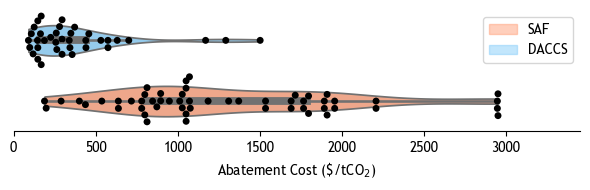

In [23]:
# Filter and rename columns
daccs_df_2050 = daccs_df[daccs_df["Term"] == "Long Term"].rename(columns={"Fully Harmonized NET REMOVED COST (incl T&S": "Fully Harmonized"})
daccs_df_2050.loc[:, "Tech"] = "DACCS"

synfuels_df_2050 = synfuels_df[synfuels_df["Term"] == "Long Term"]
synfuels_df_2050.loc[:, "Tech"] = "SAF"

# Colors
color_daccs = "lightskyblue"
color_saf = "lightsalmon"

# Combine data
combined_data = pd.concat([daccs_df_2050, synfuels_df_2050])
max_abatement_cost = combined_data["Fully Harmonized"].max()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,2), sharex=True)
plt.xlim(0,max_abatement_cost+500)


# Add swarmplot
sns.swarmplot(data=combined_data, x="Fully Harmonized", y="Tech",
              ax=ax, dodge=False, palette = ["black", "black"], alpha=1)


# Boxplot (bottom)
sns.violinplot(data=combined_data, x="Fully Harmonized", y="Tech", hue="Tech",
            ax=ax, palette= [color_daccs, color_saf], orient="h", width=0.5, fill = True, cut = 0, alpha=1)




ax.set_title("")

# Remove spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("Abatement Cost (\$/tCO$_{2}$)", fontsize=10)
ax.set_ylabel("")
ax.set_yticks([])
ax.spines["left"].set_visible(False)

# Add legend
custom_legend = [
    Patch(color=color_saf, alpha=0.5, edgecolor='black', label="SAF"),
    Patch(color=color_daccs, alpha=0.5, edgecolor='black', label="DACCS"),
]
ax.legend(handles=custom_legend, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(notebook_dir, f"{root}/outputs/{folder_name}/figures/abatement_cost_harmonized.png"))
plt.show()



## Abatment Cost Comparison Fig 4

In [24]:
file_path_abatement_cost_contributions_low = os.path.join(notebook_dir, f'{root}/outputs/{folder_name}/abatement_contributions_25%.xlsx')
file_path_abatement_cost_contributions_high = os.path.join(notebook_dir, f'{root}/outputs/{folder_name}/abatement_contributions_75%.xlsx')
file_path_abatement_cost_contributions_nominal = os.path.join(notebook_dir, f'{root}/outputs/{folder_name}/abatement_contributions_50%.xlsx')

In [25]:
abatement_cost_contributions_base_low = pd.read_excel(file_path_abatement_cost_contributions_low, sheet_name="Base Case")
abatement_cost_contributions_base_high = pd.read_excel(file_path_abatement_cost_contributions_high, sheet_name="Base Case")
abatement_cost_contributions_base_nominal = pd.read_excel(file_path_abatement_cost_contributions_nominal, sheet_name="Base Case")

abatement_cost_contributions_ca_low = pd.read_excel(file_path_abatement_cost_contributions_low, sheet_name="CA_both")
abatement_cost_contributions_ca_high = pd.read_excel(file_path_abatement_cost_contributions_high, sheet_name="CA_both")
abatement_cost_contributions_ca_nominal = pd.read_excel(file_path_abatement_cost_contributions_nominal, sheet_name="CA_both")

abatement_cost_contribution_dfs = [abatement_cost_contributions_base_low, abatement_cost_contributions_base_high, abatement_cost_contributions_base_nominal,
                                         abatement_cost_contributions_ca_low, abatement_cost_contributions_ca_high, abatement_cost_contributions_ca_nominal]


In [26]:
for df in abatement_cost_contribution_dfs:
    df.rename(columns = {'Unnamed: 0':'Method'}, inplace = True)
    df.set_index("Method", inplace=True)
    df.loc[:,"Contribution"] = df.loc[:,"Contribution"].astype(str).apply(lambda x: ufloat_fromstr(x).nominal_value)

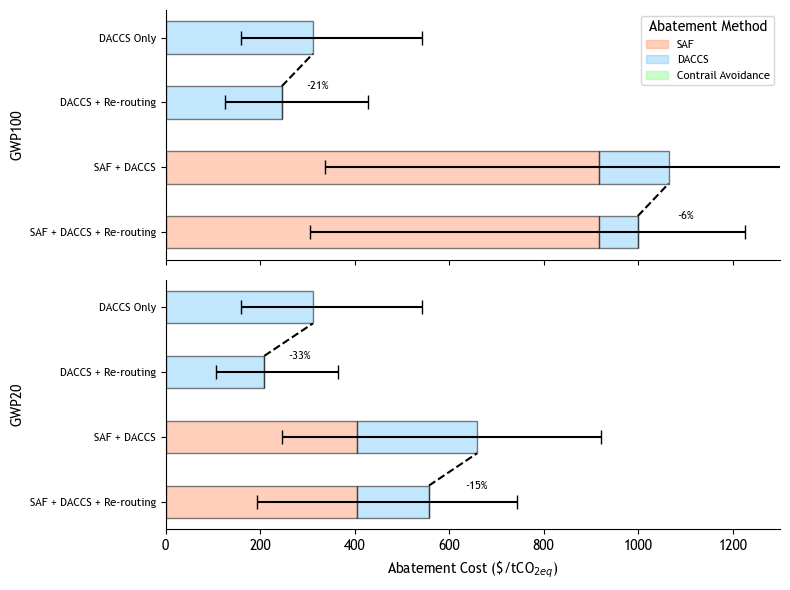

In [27]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
plt.xlim(0,1300)
# Set the bar height and positions
bar_height = 0.5  

metrics = ["GWP100", "GWP20"]
scenarios = ["SAF + DACCS + Re-routing", "SAF + DACCS", "DACCS + Re-routing", "DACCS Only"]

for i, metric in enumerate(metrics):
    # Values for the bars
    saf = abatement_cost_contributions_base_nominal.loc[f"{metric} SAF", "Contribution"]
    daccs_saf_base = abatement_cost_contributions_base_nominal.loc[f"{metric} SAF DACCS", "Contribution"]
    daccs_saf_ca = abatement_cost_contributions_ca_nominal.loc[f"{metric} SAF DACCS", "Contribution"]

    ca = abatement_cost_contributions_ca_nominal.loc[f"{metric} Contrail Avoidance SAF", "Contribution"]
    #ca = 100  # For testing
    daccs_base = abatement_cost_contributions_base_nominal.loc[f"{metric} BAU DACCS", "Contribution"]
    daccs_ca = abatement_cost_contributions_ca_nominal.loc[f"{metric} BAU DACCS", "Contribution"]

    # Values for errorbars 
    saf_low = abatement_cost_contributions_base_low.loc[f"{metric} SAF", "Contribution"]
    saf_high = abatement_cost_contributions_base_high.loc[f"{metric} SAF", "Contribution"]

    daccs_base_low = abatement_cost_contributions_base_low.loc[f"{metric} BAU DACCS", "Contribution"]
    daccs_base_high = abatement_cost_contributions_base_high.loc[f"{metric} BAU DACCS", "Contribution"]

    daccs_ca_low = abatement_cost_contributions_ca_low.loc[f"{metric} BAU DACCS", "Contribution"]
    daccs_ca_high = abatement_cost_contributions_ca_high.loc[f"{metric} BAU DACCS", "Contribution"]

    daccs_saf_base_low = abatement_cost_contributions_base_low.loc[f"{metric} SAF DACCS", "Contribution"]
    daccs_saf_base_high = abatement_cost_contributions_base_high.loc[f"{metric} SAF DACCS", "Contribution"]

    daccs_saf_ca_low = abatement_cost_contributions_ca_low.loc[f"{metric} SAF DACCS", "Contribution"]
    daccs_saf_ca_high = abatement_cost_contributions_ca_high.loc[f"{metric} SAF DACCS", "Contribution"]

    total_costs = {key:0 for key in scenarios}
    for j, scenario in enumerate(scenarios):
        y_pos = j  # Assign each scenario a position on the y-axis
        total_cost = 0  # Track the total cost to position CA at the rightmost end
         

        if scenario == "SAF + DACCS":
            axs[i].barh(y_pos, saf, height=bar_height, color=color_saf, alpha=0.5, edgecolor='black', label="SAF" if j == 0 else "")
            total_cost += saf
            axs[i].barh(y_pos, daccs_saf_base, left=total_cost, height=bar_height, color=color_daccs, alpha=0.5, edgecolor='black', label="DACCS" if j == 0 else "")
            total_cost += daccs_saf_base
            total_costs[scenario] = total_cost

            # Error bar part
            err_low = saf_low + daccs_saf_base_low
            err_high = saf_high + daccs_saf_base_high

            axs[i].errorbar(total_cost, y_pos, xerr=[[total_cost - err_low], [err_high - total_cost]], color='black', capsize=5, capthick=1, fmt='none')

            # Dashed line showing decreaase in cost from SAF + DACCS to SAF + DACCS + Re-routing
            axs[i].plot([total_costs["SAF + DACCS + Re-routing"], total_costs["SAF + DACCS"]], [y_pos - 1 + bar_height/2, y_pos - bar_height/2], color='black', linestyle='--', linewidth=1.5)
            pct_change = ((total_costs["SAF + DACCS + Re-routing"] - total_costs["SAF + DACCS"]) / total_costs["SAF + DACCS"] * 100)
            axs[i].text(total_costs["SAF + DACCS + Re-routing"] + 100, y_pos - 1 + bar_height/2, f"{pct_change:.0f}%", fontsize=8, color='black', ha='center', va='center')

        elif scenario == "SAF + DACCS + Re-routing":

            axs[i].barh(y_pos, saf, height=bar_height, color=color_saf, alpha =0.5, edgecolor='black', label="SAF + DACCS" if j == 0 else "")
            total_cost += saf
            axs[i].barh(y_pos, daccs_saf_ca, left=total_cost, height=bar_height, color=color_daccs, alpha=0.5, edgecolor='black', label="DACCS" if j == 0 else "")
            total_cost += daccs_saf_ca
            axs[i].barh(y_pos, ca, left=total_cost, height=bar_height, color=color_contrail, alpha=0.5, edgecolor='black', label="Contrail Avoidance" if j == 0 else "")

            err_low = saf_low + daccs_saf_ca_low
            err_high = saf_high + daccs_saf_ca_high
            axs[i].errorbar(total_cost, y_pos, xerr=[[total_cost - err_low], [err_high - total_cost]], color='black', capsize=5, capthick=1, fmt='none')

            current_val = total_cost

            total_costs[scenario] = total_cost


        elif scenario == "DACCS Only":
            axs[i].barh(y_pos, daccs_base, height=bar_height, color=color_daccs, alpha= 0.5, edgecolor='black')
            total_cost += daccs_base

            err_low = daccs_base_low
            err_high = daccs_base_high
            axs[i].errorbar(total_cost, y_pos, xerr=[[total_cost - err_low], [err_high - total_cost]], color='black', capsize=5, capthick=1, fmt='none')

            total_costs[scenario] = total_cost

            # Dashed line showing decreaase in cost from DACCS to DACCS + Re-routing
            axs[i].plot([total_costs["DACCS + Re-routing"], total_costs["DACCS Only"]], [y_pos - 1 + bar_height/2, y_pos - bar_height/2], color='black', linestyle='--', linewidth=1.5)
            pct_change = ((total_costs["DACCS + Re-routing"] - total_costs["DACCS Only"]) / total_costs["DACCS Only"] * 100)
            axs[i].text(total_costs["DACCS + Re-routing"] + 75, y_pos - 1 + bar_height/2, f"{pct_change:.0f}%", fontsize=8, color='black', ha='center', va='center')

        elif scenario == "DACCS + Re-routing":
            axs[i].barh(y_pos, daccs_ca, height=bar_height, color=color_daccs, alpha=0.5, edgecolor='black')
            total_cost += daccs_ca
            axs[i].barh(y_pos, ca, left=total_cost, height=bar_height, color=color_contrail, alpha= 0.5, edgecolor='black')

            err_low = daccs_ca_low
            err_high = daccs_ca_high
            axs[i].errorbar(total_cost, y_pos, xerr=[[total_cost - err_low], [err_high - total_cost]], color='black', capsize=5, capthick=1, fmt='none')

            total_costs[scenario] = total_cost



    axs[i].set_yticks(range(len(scenarios)))
    axs[i].set_yticklabels(scenarios, fontsize=8)
    # Set y axis title as the metric name
    axs[i].set_ylabel(metric)

# custom legend with DACCS, SAF and contrail avoidance patches in the top right corner

custom_legend = [
    Patch(color=color_saf, alpha=0.5, edgecolor='black', label="SAF"),
    Patch(color=color_daccs, alpha=0.5, edgecolor='black', label="DACCS"),
    Patch(color=color_contrail, alpha=0.5, edgecolor='black', label="Contrail Avoidance"),
]

axs[0].legend(handles=custom_legend, loc='upper right', fontsize=8, title="Abatement Method", title_fontsize=10)

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.xlabel("Abatement Cost (\$/tCO$_{2eq}$)")
plt.tight_layout()
plt.savefig(os.path.join(notebook_dir, f"{root}/outputs/{folder_name}/figures/abatement_cost_contributions_600.png"), dpi = 600, bbox_inches='tight')
plt.show()


## Abatement Cost Figure 4 (Old)

In [28]:
abatement_cost_gwp_20_saf_base = pd.read_excel(file_path_gwp_20_saf, sheet_name="Base Case")
abatement_cost_gwp_100_saf_base = pd.read_excel(file_path_gwp_100_saf, sheet_name="Base Case")

abatement_cost_gwp_20_saf_ca = pd.read_excel(file_path_gwp_20_saf, sheet_name="CA_both")
abatement_cost_gwp_100_saf_ca = pd.read_excel(file_path_gwp_100_saf, sheet_name="CA_both")

abatement_cost_gwp_20_daccs_base = pd.read_excel(file_path_gwp_20_daccs, sheet_name="Base Case")
abatement_cost_gwp_100_daccs_base = pd.read_excel(file_path_gwp_100_daccs, sheet_name="Base Case")

abatement_cost_gwp_20_daccs_ca = pd.read_excel(file_path_gwp_20_daccs, sheet_name="CA_both")
abatement_cost_gwp_100_daccs_ca = pd.read_excel(file_path_gwp_100_daccs, sheet_name="CA_both")

abatement_cost_comparison_df_list = [abatement_cost_gwp_20_saf_base, abatement_cost_gwp_100_saf_base, 
                                     abatement_cost_gwp_20_saf_ca, abatement_cost_gwp_100_saf_ca, 
                                     abatement_cost_gwp_20_daccs_base, abatement_cost_gwp_100_daccs_base, 
                                     abatement_cost_gwp_20_daccs_ca, abatement_cost_gwp_100_daccs_ca]

In [29]:
for df in abatement_cost_comparison_df_list:
    df.rename(columns = {'Unnamed: 0':'Quartile'}, inplace = True)
    df.loc[:,"Abatement Cost $ per tCO2eq"] = df.loc[:,"Abatement Cost $ per tCO2eq"].astype(str).apply(lambda x: ufloat_fromstr(x))

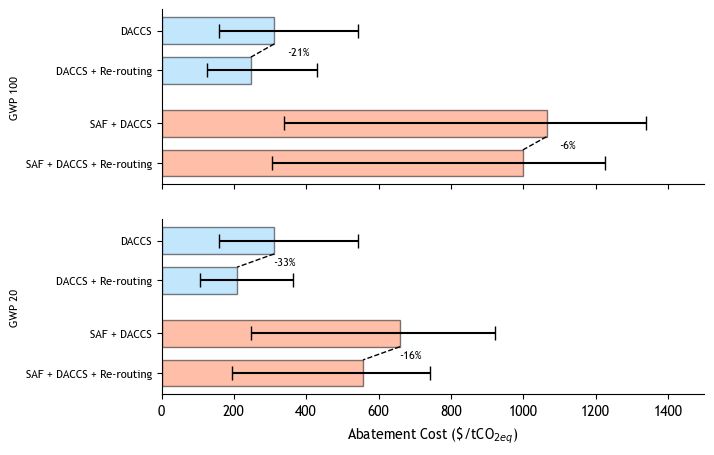

In [30]:
def extract_costs(df):
    try:
        return {
            "median": df.loc[df["Quartile"] == "50%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value,
            "lower": df.loc[df["Quartile"] == "25%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value,
            "upper": df.loc[df["Quartile"] == "75%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value,
        }
    except KeyError:
        return{
            "median": df.loc[df["Unnamed: 0"] == "50%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value,
            "lower" : df.loc[df["Unnamed: 0"] == "25%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value,
            "upper" : df.loc[df["Unnamed: 0"] == "75%", "Abatement Cost $ per tCO2eq"].values[0].nominal_value,
        }

def plot_bar(ax, y_pos, costs, color, gwp, title=None,sensitivity = False):
    ax.barh(y_pos, costs["median"], bar_height, color=color, alpha=0.5, edgecolor='black')
    ax.errorbar(costs["median"], y_pos, 
                xerr=[[costs["median"] - costs["lower"]], [costs["upper"] - costs["median"]]], 
                color='black', capsize=5, capthick=1, fmt='none')
    
    ax.set_ylabel(gwp, fontdict={'fontsize': 8}, rotation=90)
    
    if sensitivity and title is not None:
        ax.text(-0.8, 1.3, title, transform=ax.transAxes, 
                fontdict={'fontsize': 10}, 
                verticalalignment='center', horizontalalignment='left')
        
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontdict={'fontsize': 8})

    

# Setup plot
fig, axs = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
plt.xlim(0, 1500)
bar_height = 0.01
color_saf, color_daccs = 'coral', 'lightskyblue'

# Extract cost data
gwp_data = {
    "GWP 100": {
        "SAF + DACCS": extract_costs(abatement_cost_gwp_100_saf_base),
        "SAF + DACCS + Re-routing": extract_costs(abatement_cost_gwp_100_saf_ca),
        "DACCS": extract_costs(abatement_cost_gwp_100_daccs_base),
        "DACCS + Re-routing": extract_costs(abatement_cost_gwp_100_daccs_ca),
    },
    "GWP 20": {
        "SAF + DACCS": extract_costs(abatement_cost_gwp_20_saf_base),
        "SAF + DACCS + Re-routing": extract_costs(abatement_cost_gwp_20_saf_ca),
        "DACCS": extract_costs(abatement_cost_gwp_20_daccs_base),
        "DACCS + Re-routing": extract_costs(abatement_cost_gwp_20_daccs_ca),
    }
}

# Plot data
y_positions = [-bar_height, -2.5* bar_height, 2.5 * bar_height, bar_height]
colors = [color_saf, color_saf, color_daccs, color_daccs]
labels = ["SAF + DACCS", "SAF + DACCS + Re-routing", "DACCS", "DACCS + Re-routing"]

for i, (gwp, data) in enumerate(gwp_data.items()):
    for y_pos, label, color in zip(y_positions, labels, colors):

        if label in ["SAF + DACCS", "DACCS"]:
            base_value = data[label]["median"]

        if label in ["SAF + DACCS + Re-routing", "DACCS + Re-routing"]:
            new_value  = data[label]["median"]
            pct_change = ((new_value - base_value) * 100) / base_value
            axs[i].text(
                new_value + 100 , y_pos + bar_height/1.5, f"{pct_change:.0f}%", color="black", fontsize=8,
                verticalalignment='center', horizontalalignment='left'
            )
            axs[i].plot(
                [base_value, new_value], [y_pos + bar_height, y_pos + bar_height/2], color="black", linestyle='--', linewidth=1
            )

        plot_bar(axs[i], y_pos, data[label], color,gwp)

axs[1].set_xlabel("Abatement Cost (\$/tCO$_{2eq}$)")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(notebook_dir, f"{root}/outputs/{folder_name}/figures/abatement_cost_comparison.png"))

plt.show()

## Sensitivity Analysis

In [31]:
sensitivity_scenarios = ["Default", "HF", "LE", "CA", "HF_CA", "HF_LE", "LE_CA", "HF_LE_CA"]
title_mapper = {
    "Default": "Base Case",
    "HF" : "Fossil Fuel Price Sesitivity",
    "LE" : "Electricity Price Sensitivity",
    "CA" : "Contrail Avoidance Sensitivity",
    "HF_CA" : "Fossil Fuel Price + Contrail Avoidance Sensitivity",
    "HF_LE" : "Fossil Fuel Price + Low Electricity Price Sensitivity",
    "LE_CA" : "Low Electricity Price + Contrail Avoidance Sensitivity",
    "HF_LE_CA" : "All Sensitivities"
}
sensitivity_scenario_dfs = {}
for folder in sensitivity_scenarios:
    if folder not in sensitivity_scenario_dfs:
        sensitivity_scenario_dfs[folder] = {}
    for gwp in ["GWP100", "GWP20"]:
        for tech in ["SAF", "DACCS"]:
            if tech not in sensitivity_scenario_dfs[folder]:
                sensitivity_scenario_dfs[folder][tech] = {}
            if gwp not in sensitivity_scenario_dfs[folder][tech]:
                sensitivity_scenario_dfs[folder][tech][gwp] = {}
            for scenario in ["Base Case", "CA_both"]:
                path = os.path.join(notebook_dir, root, "outputs", folder_name_base, folder, f'abatement_costs_{tech}_{gwp}.xlsx')
                #print(path)
                df = pd.read_excel(path, sheet_name=scenario)
                df.rename(columns={"Unnamed: 0": "Quartile"}, inplace=True)
                df.loc[:,"Abatement Cost $ per tCO2eq"] = df.loc[:,"Abatement Cost $ per tCO2eq"].astype(str).apply(lambda x: ufloat_fromstr(x))
                sensitivity_scenario_dfs[folder][tech][gwp][scenario] = df

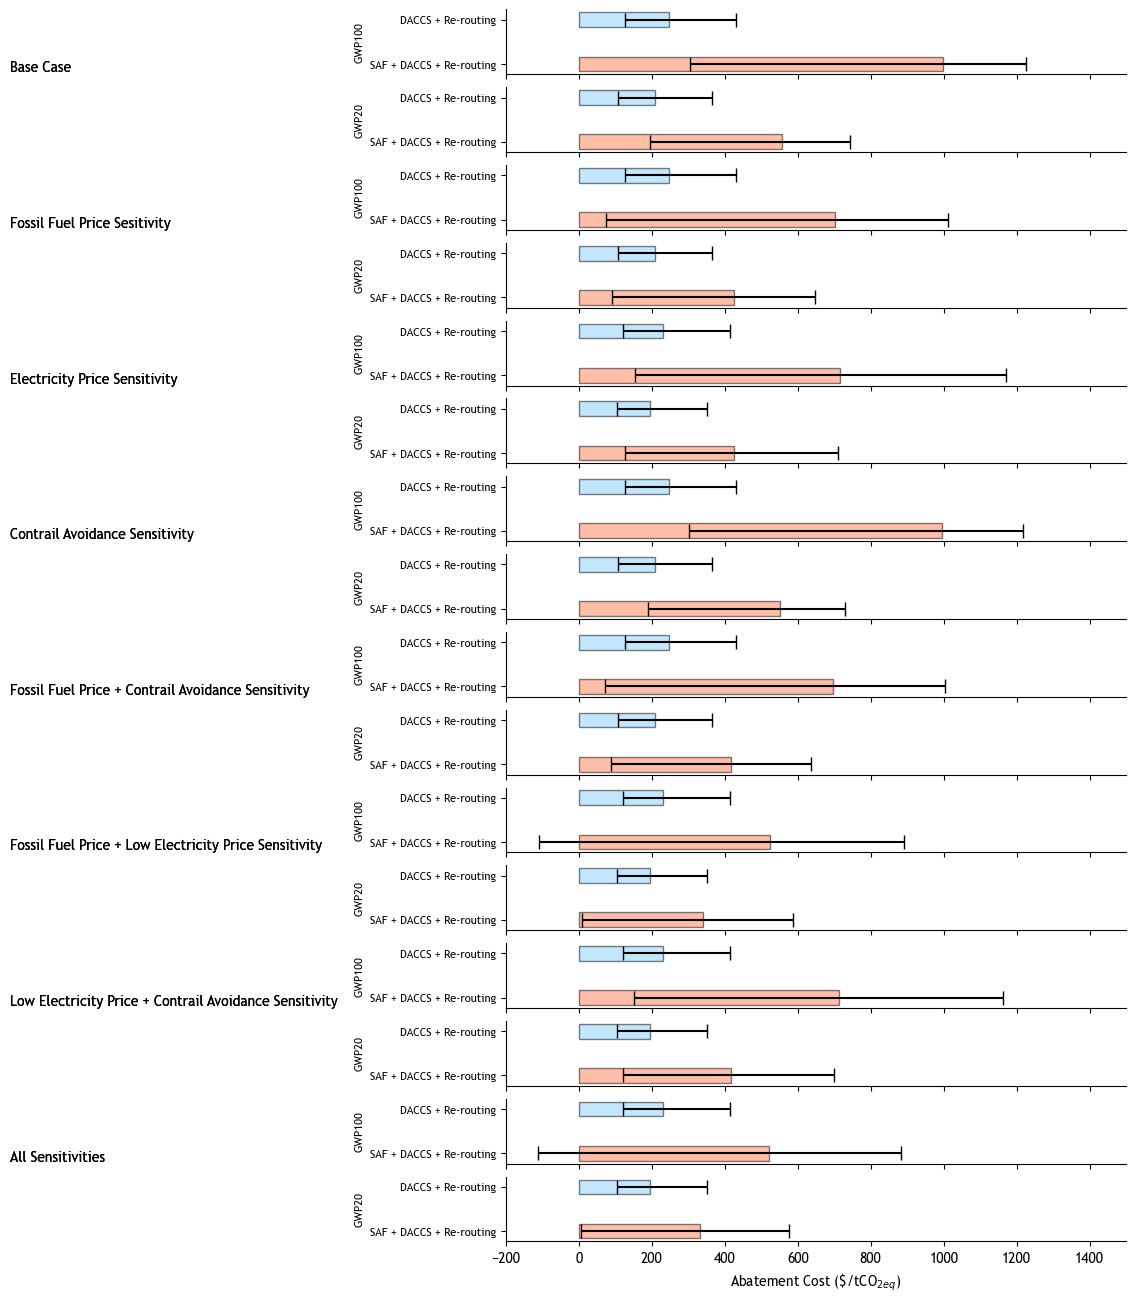

In [32]:
fig, axs = plt.subplots(16, 1, figsize=(8, 16), sharex=True)
plt.xlim(-200, 1500)
bar_height = 0.01
color_saf, color_daccs = 'coral', 'lightskyblue'

scenario_count = 0
for sensitivity_scenario in sensitivity_scenarios:

    gwp_data = {
        "GWP100": {
            "SAF + DACCS + Re-routing" : extract_costs(sensitivity_scenario_dfs[sensitivity_scenario]["SAF"]["GWP100"]["CA_both"]),
            "DACCS + Re-routing" : extract_costs(sensitivity_scenario_dfs[sensitivity_scenario]["DACCS"]["GWP100"]["CA_both"]),
        },
        "GWP20": {
            "SAF + DACCS + Re-routing" : extract_costs(sensitivity_scenario_dfs[sensitivity_scenario]["SAF"]["GWP20"]["CA_both"]),
            "DACCS + Re-routing" : extract_costs(sensitivity_scenario_dfs[sensitivity_scenario]["DACCS"]["GWP20"]["CA_both"]),
        }
    }

    y_positions = [-2 * bar_height, bar_height]
    colors = [color_saf, color_daccs]
    labels = ["SAF + DACCS + Re-routing", "DACCS + Re-routing"]

    for i, (gwp, data) in enumerate(gwp_data.items()):
        for y_pos, label, color in zip(y_positions, labels, colors):
            current_axs = scenario_count + i

            title = title_mapper[sensitivity_scenario] if current_axs % 2 != 0 else None

            new_value = data[label]["median"]


            plot_bar(axs[current_axs], y_pos, data[label], color, gwp, title=title, sensitivity=True)
    
    scenario_count += 2

    axs[-1].set_xlabel("Abatement Cost (\$/tCO$_{2eq}$)")

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.show()


## Figure 2 GWP Star

In [33]:
gwp_star_emissions = pd.read_csv(os.path.join(notebook_dir, f"{root}/outputs/{folder_name}/gwp_star.csv"))

In [34]:
gwp_star_emissions = gwp_star_emissions.rename(columns={"Unnamed: 0": "Route"})
gwp_star_emissions = gwp_star_emissions.set_index("Route")

In [35]:

gwp_star_emissions = gwp_star_emissions.apply(lambda x: x.astype(str).apply(lambda y: ufloat_fromstr(y)))

In [36]:
gwp_star_emissions.rename(columns = {"SO2":"Sulfate", "BC" : "Soot", "Contrail Cirrus and C-C" : "Contrail Cirrus"}, inplace = True)

In [37]:
gwp_star_emissions.loc["GWP* BAU"] - gwp_star_emissions.loc["GWP* SAF"]

NOx                 (0.0+/-2.3)e+02
Sulfate            (-1.0+/-0.8)e+02
Soot                         4+/-26
H2O                         -4+/-21
Contrail Cirrus         (1+/-8)e+02
CO2                    1541.0+/-1.0
Total               (1.5+/-0.8)e+03
dtype: object

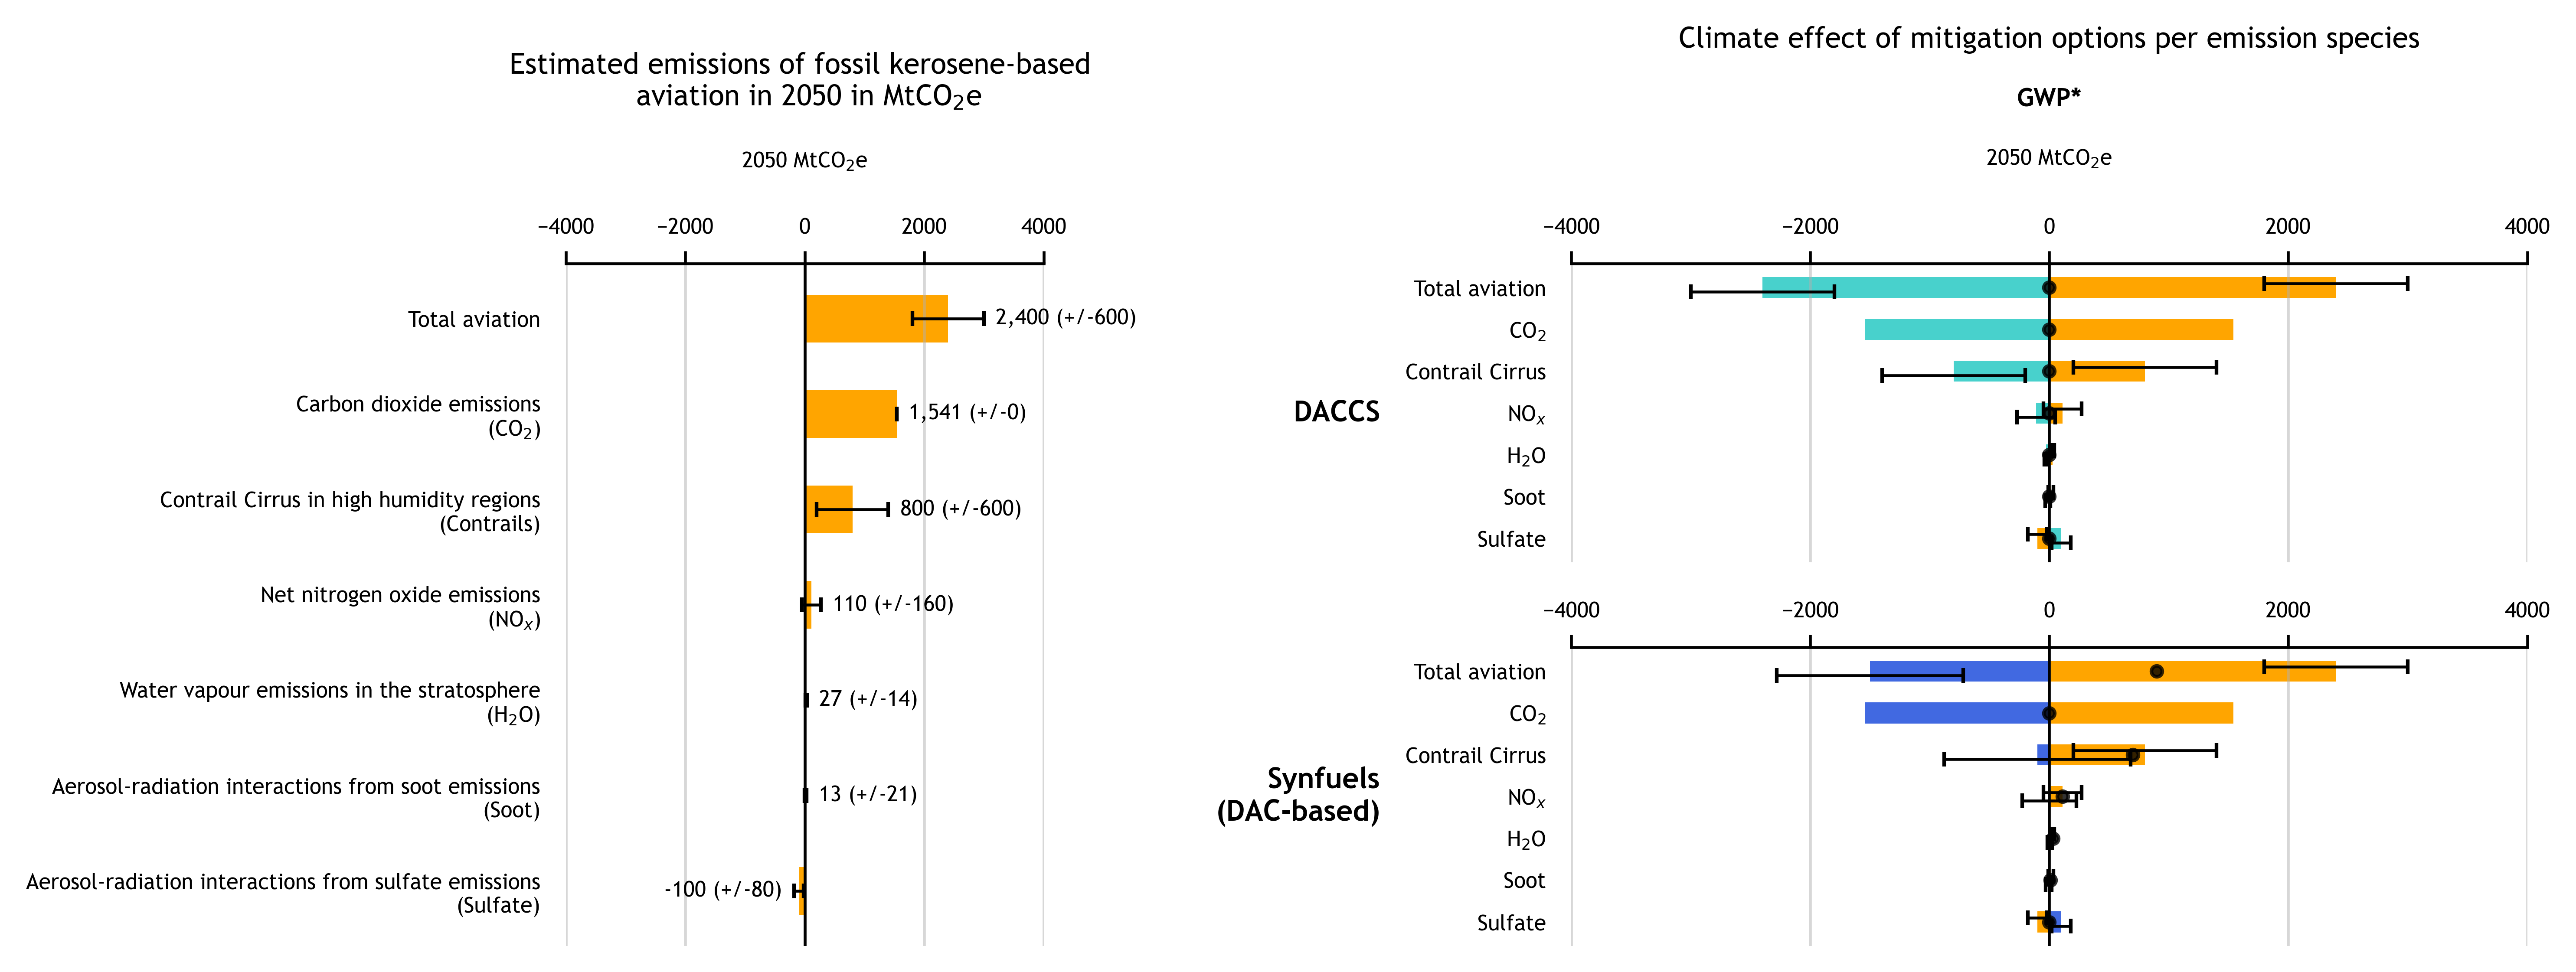

In [38]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Create figure with custom layout
fig = plt.figure(figsize=(10, 4), dpi=600)
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2])

# Axes: 1 tall on the left, 2 stacked on the right
ax_bau = fig.add_subplot(gs[:, 0])
ax_daccs = fig.add_subplot(gs[0, 1])
ax_saf = fig.add_subplot(gs[1, 1])
axs = [ax_bau, ax_daccs, ax_saf]

# Common settings
for ax in axs:
    ax.set_xlim(-4000, 4000)
    ax.set_xticks(range(-4000, 4001, 2000))

# Data and visual settings (assuming gwp_star_emissions exists)
bar_width = 0.5
color_daccs_emissions = "mediumturquoise"
color_saf_emissions = "royalblue"
color_gwp_star_emissions = "orange"
labels = {
    "Total": "Total aviation", "CO2": r"CO$_2$", "Contrail Cirrus": "Contrail Cirrus",
    "NOx": r"NO$_x$", "H2O": r"H$_2$O",
    "Soot": "Soot", "Sulfate": "Sulfate"
}

labels_bau = {
    "Total": "Total aviation",
    "CO2": "Carbon dioxide emissions\n(CO$_2$)",
    "Contrail Cirrus": "Contrail Cirrus in high humidity regions\n(Contrails)",
    "NOx": "Net nitrogen oxide emissions\n(NO$_x$)",
    "H2O": "Water vapour emissions in the stratosphere\n(H$_2$O)",
    "Soot": "Aerosol-radiation interactions from soot emissions\n(Soot)",
    "Sulfate": "Aerosol-radiation interactions from sulfate emissions\n(Sulfate)"
}
bau_emissions = gwp_star_emissions.loc["GWP* BAU"]
saf_reductions = gwp_star_emissions.loc["GWP* BAU"] - gwp_star_emissions.loc["GWP* SAF"]
remaining_emissions_saf = gwp_star_emissions.loc["GWP* SAF"]
remaining_emissions_daccs = gwp_star_emissions.loc["GWP* BAU"] - gwp_star_emissions.loc["GWP* BAU"]  # Zero
daccs_reductions = gwp_star_emissions.loc["GWP* BAU"]

# Plot BAU emissions (full column)
for i, (emission, label) in enumerate(reversed(labels_bau.items())):
    bau_value = bau_emissions[emission]
    ax_bau.barh(i, bau_value.nominal_value, height=bar_width, color=color_gwp_star_emissions, label="GWP*" if i == 0 else "")
    ax_bau.errorbar(bau_value.nominal_value, i, xerr=bau_value.std_dev, color="black", capsize=2, fmt="none", linewidth=0.8)
    if emission != "Sulfate":
        ax_bau.text(
            bau_value.nominal_value + bau_value.std_dev + 200, 
            i, 
            f"{bau_value.nominal_value:,.0f} (+/-{bau_value.std_dev:,.0f})", 
            fontsize=6, 
            va='center', 
            ha='left'
        )
    else:
        ax_bau.text(
            bau_value.nominal_value - bau_value.std_dev - 200, 
            i, 
            f"{bau_value.nominal_value:,.0f} (+/-{bau_value.std_dev:,.0f})", 
            fontsize=6, 
            va='center', 
            ha='right'
        )
# DACCS plot (top right)
for i, (emission, label) in enumerate(reversed(labels.items())):
    daccs_bau = bau_emissions[emission]
    daccs_reduction = daccs_reductions[emission]
    remaining_daccs = remaining_emissions_daccs[emission]
    ax_daccs.barh(i, daccs_bau.nominal_value, height=bar_width, color=color_gwp_star_emissions, label="GWP*" if i == 0 else "")
    ax_daccs.barh(i, -daccs_reduction.nominal_value, height=bar_width, color=color_daccs_emissions, label="DACCS" if i == 0 else "")
    ax_daccs.scatter(remaining_daccs.nominal_value, i, s=9, color="black", alpha=0.8, zorder=3)

    if emission != "CO2":
        ax_daccs.errorbar(daccs_bau.nominal_value, i + 0.1, xerr=daccs_bau.std_dev, color="black", capsize=2, fmt="none", linewidth=0.8)
        ax_daccs.errorbar(-daccs_reduction.nominal_value, i - 0.1, xerr=daccs_reduction.std_dev, color="black", capsize=2, fmt="none", linewidth=0.8)

# SAF plot (bottom right)
for i, (emission, label) in enumerate(reversed(labels.items())):
    saf_bau = bau_emissions[emission]
    saf_reduction = saf_reductions[emission]
    remaining_saf = remaining_emissions_saf[emission]
    ax_saf.barh(i, saf_bau.nominal_value, height=bar_width, color=color_gwp_star_emissions, label="GWP*" if i == 0 else "")
    ax_saf.barh(i, -saf_reduction.nominal_value, height=bar_width, color=color_saf_emissions, label="SAF" if i == 0 else "")
    ax_saf.scatter(remaining_saf.nominal_value, i, s=9, color="black", alpha=0.8, zorder=3)

    if emission != "CO2":
        ax_saf.errorbar(saf_bau.nominal_value, i + 0.1, xerr=saf_bau.std_dev, color="black", capsize=2, fmt="none", linewidth=0.8)
        ax_saf.errorbar(-saf_reduction.nominal_value, i - 0.1, xerr=saf_reduction.std_dev, color="black", capsize=2, fmt="none", linewidth=0.8)

# Customize all plots
for ax in axs:
    if ax == ax_bau:
        ax.set_yticks(range(len(labels_bau)))
        ax.set_yticklabels(list(reversed(labels_bau.values())), fontsize=6)
    else:
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(list(reversed(labels.values())), fontsize=6)
    ax.xaxis.grid(True, linestyle='-', alpha=0.5)
    ax.tick_params(axis='x', labelsize=6)
    ax.tick_params(axis='y', which='both', left=False, right=False)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="-")
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    #ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

# Titles
ax_daccs.set_ylabel("DACCS", fontsize=8, labelpad=0.5, weight="bold", rotation=0, ha='right', va='center')
ax_saf.set_ylabel("Synfuels\n(DAC-based)", fontsize=8, labelpad=0.5, weight="bold", rotation=0, ha='right', va='center')
ax_daccs.yaxis.set_label_coords(-0.2, 0.5)
ax_saf.yaxis.set_label_coords(-0.2, 0.5)
ax_bau.set_title("Estimated emissions of fossil kerosene-based \n aviation in 2050 in MtCO$_2$e ", fontsize=8, y=1.2)
ax_daccs.set_title("Climate effect of mitigation options per emission species", fontsize=8, y=1.65)




ax_bau.text(0.5, 1.15, "2050 MtCO$_2$e", transform=ax_bau.transAxes, fontsize=6, ha='center', va='center')
ax_daccs.text(0.5, 1.55, "GWP*", transform=ax_daccs.transAxes, fontsize=7, ha='center', va='center', weight='bold')
ax_daccs.text(0.5, 1.35, "2050 MtCO$_2$e", transform=ax_daccs.transAxes, fontsize=6, ha='center', va='center')

plt.tight_layout()
plt.show()
